#Blurr
A wrapper that wraps fastai and HuggingFace which gives us the ability to utilize two of the most powerful ML frameworks together to conquer what we want to.  <br/>
See documentation: https://ohmeow.github.io/blurr/





In [1]:
!nvidia-smi

Sun Aug 23 19:06:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%matplotlib inline

In [3]:
! pip install -q transformers[sentencepiece] fastbook fastai nbdev plum-dispatch evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.1/364.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 78.8 MB/s eta 0:00:00


In [4]:
!git clone https://github.com/msi1427/blurr.git
%cd blurr

Cloning into 'blurr'...
remote: Enumerating objects: 5063, done.
remote: Counting objects: 100% (894/894), done.
remote: Compressing objects: 100% (311/311), done.
remote: Total 5063 (delta 705), reused 702 (delta 576), pack-reused 4169 (from 1)
Receiving objects: 100% (5063/5063), 26.85 MiB | 16.10 MiB/s, done.
Resolving deltas: 100% (3934/3934), done.
/content/blurr


In [5]:
import torch
from transformers import AutoModelForSequenceClassification, AutoConfig
from fastai.text.all import *
from blurr.text.data.all import *
from blurr.text.modeling.all import *

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
%cd /content/drive/MyDrive/udemy_project/Text Classification with Blurr


/content/drive/MyDrive/udemy_project/Text Classification with Blurr


#Data

In [8]:
df = pd.read_csv("/content/drive/MyDrive/udemy_project/Datasets/course_details.csv")
df.head()

,title,url,description,topic,topic_list
0,The Complete Python Bootcamp From Zero to Hero in Python,https://www.udemy.com/course/complete-python-bootcamp,"Become a Python Programmer and learn one of employer's most requested skills of 2023! This is the most comprehensive, yet straight-forward, course for the Python programming language on Udemy! Whether you have never programmed before, already know basic syntax, or want to learn about the advanced features of Python, this course is for you! In this course we will teach you Python 3. With over 100 lectures and more than 21 hours of video this comprehensive course leaves no stone unturned! This course includes quizzes, tests, coding exercises and homework assignments as well as 3 major projec...",Python,"['Development', 'Programming Languages', 'Python']"
1,The Complete Full-Stack Web Development Bootcamp,https://www.udemy.com/course/the-complete-web-development-bootcamp,"Welcome to the Complete Web Development Bootcamp, the only course you need to learn to code and become a full-stack web developer. With 150,000+ ratings and a 4.8 average, my Web Development course is one of the HIGHEST RATED courses in the history of Udemy! At 62+ hours, this Web Development course is without a doubt the most comprehensive web development course available online. Even if you have zero programming experience, this course will take you from beginner to mastery. Here's why: The course is taught by the lead instructor at the App Brewery, London's leading in-person programmin...",Web Development,"['Development', 'Web Development', 'Node.Js', 'MongoDB', 'JavaScript']"
2,100 Days of Code™: The Complete Python Pro Bootcamp,https://www.udemy.com/course/100-days-of-code,"Welcome to the 100 Days of Code - The Complete Python Pro Bootcamp, the only course you need to learn to code with Python. With over 500,000 5 STAR reviews and a 4.8 average, my courses are some of the HIGHEST RATED courses in the history of Udemy! 100 days, 1 hour per day, learn to build 1 project per day, this is how you master Python. At 60+ hours, this Python course is without a doubt the most comprehensive Python course available anywhere online. Even if you have zero programming experience, this course will take you from beginner to professional. Here's why: The course is taught by...",Python,"['Development', 'Programming Languages', 'Python', 'Data Science', 'Flask', 'Web Scraping']"
3,The Web Developer Bootcamp 2026,https://www.udemy.com/course/the-web-developer-bootcamp,"Now with over 10 hours of React content. Massive new React ""expansion pack"" covers: React basics, JSX, props, state, Vite, MaterialUI, hooks, useEffect, React design patterns, and more. Hi! Welcome to the brand new version of The Web Developer Bootcamp, Udemy's most popular web development course. This course was completely overhauled to prepare students for the current job market, now with over 70 hours of total content! This is the only course you need to learn web development. There are a lot of options for online developer training, but this course is without a doubt the most comprehe...",Web Development,"['Development', 'Web Development']"
4,"React - The Complete Guide (incl. Next.js, Redux)",https://www.udemy.com/course/react-the-complete-guide-incl-redux,"This bestselling course by the author of ""React Key Concepts"" has turned more students into ReactJS developers than any other courses - more than 1,000,000 and counting! - Fully updated for React 19! - A Course For Busy Customers & Business Professionals! This course also comes with two paths which you can take: The ""complete"" path (full >40h course) and the ""summary"" (fast-track) path (~4h summary module) - you can choose the path that best fits your time requirements! React.js is THE most popular JavaScript library you can use and learn these days to build modern, reactive user interfa...",React JS,"['Development', 'Programming Languages', 'React JS', 'React Hooks']"


In [9]:
topic_list = []
indices_to_drop = []
for idx, topics in enumerate(df.topic_list.to_list()):
  topics_list = eval(topics)
  if len(topics_list):
    topic_list.append(topics_list[0])
  else:
    indices_to_drop.append(idx)

df = df.drop(indices_to_drop).reset_index(drop=True)
df.shape

(11057, 5)

In [10]:
df['primary_topic'] = topic_list

In [11]:
topic_count = df['primary_topic'].value_counts()
threshold = int(len(df) * 0.005)
rare_topics = [cat for cat, count in topic_count.items() if count < threshold]
len(rare_topics), rare_topics[:5]

(3, ['Udemy Free Resource Center', 'Vodafone', 'Health & Fitness'])

In [12]:
rare_indices_to_drop = [idx for idx, row in df.iterrows() if row['primary_topic'] in rare_topics]
df = df.drop(rare_indices_to_drop).reset_index(drop=True)
df.shape

(11041, 6)

In [13]:
labels = list(set(df.primary_topic.to_list()))
label_count = len(labels)
labels, label_count

(['Development',
  'IT & Software',
  'Marketing',
  'Business',
  'Personal Development',
  'Design',
  'Finance & Accounting'],
 7)

In [14]:
df.head()

,title,url,description,topic,topic_list,primary_topic
0,The Complete Python Bootcamp From Zero to Hero in Python,https://www.udemy.com/course/complete-python-bootcamp,"Become a Python Programmer and learn one of employer's most requested skills of 2023! This is the most comprehensive, yet straight-forward, course for the Python programming language on Udemy! Whether you have never programmed before, already know basic syntax, or want to learn about the advanced features of Python, this course is for you! In this course we will teach you Python 3. With over 100 lectures and more than 21 hours of video this comprehensive course leaves no stone unturned! This course includes quizzes, tests, coding exercises and homework assignments as well as 3 major projec...",Python,"['Development', 'Programming Languages', 'Python']",Development
1,The Complete Full-Stack Web Development Bootcamp,https://www.udemy.com/course/the-complete-web-development-bootcamp,"Welcome to the Complete Web Development Bootcamp, the only course you need to learn to code and become a full-stack web developer. With 150,000+ ratings and a 4.8 average, my Web Development course is one of the HIGHEST RATED courses in the history of Udemy! At 62+ hours, this Web Development course is without a doubt the most comprehensive web development course available online. Even if you have zero programming experience, this course will take you from beginner to mastery. Here's why: The course is taught by the lead instructor at the App Brewery, London's leading in-person programmin...",Web Development,"['Development', 'Web Development', 'Node.Js', 'MongoDB', 'JavaScript']",Development
2,100 Days of Code™: The Complete Python Pro Bootcamp,https://www.udemy.com/course/100-days-of-code,"Welcome to the 100 Days of Code - The Complete Python Pro Bootcamp, the only course you need to learn to code with Python. With over 500,000 5 STAR reviews and a 4.8 average, my courses are some of the HIGHEST RATED courses in the history of Udemy! 100 days, 1 hour per day, learn to build 1 project per day, this is how you master Python. At 60+ hours, this Python course is without a doubt the most comprehensive Python course available anywhere online. Even if you have zero programming experience, this course will take you from beginner to professional. Here's why: The course is taught by...",Python,"['Development', 'Programming Languages', 'Python', 'Data Science', 'Flask', 'Web Scraping']",Development
3,The Web Developer Bootcamp 2026,https://www.udemy.com/course/the-web-developer-bootcamp,"Now with over 10 hours of React content. Massive new React ""expansion pack"" covers: React basics, JSX, props, state, Vite, MaterialUI, hooks, useEffect, React design patterns, and more. Hi! Welcome to the brand new version of The Web Developer Bootcamp, Udemy's most popular web development course. This course was completely overhauled to prepare students for the current job market, now with over 70 hours of total content! This is the only course you need to learn web development. There are a lot of options for online developer training, but this course is without a doubt the most comprehe...",Web Development,"['Development', 'Web Development']",Development
4,"React - The Complete Guide (incl. Next.js, Redux)",https://www.udemy.com/course/react-the-complete-guide-incl-redux,"This bestselling course by the author of ""React Key Concepts"" has turned more students into ReactJS developers than any other courses - more than 1,000,000 and counting! - Fully updated for React 19! - A Course For Busy Customers & Business Professionals! This course also comes with two paths which you can take: The ""complete"" path (full >40h course) and the ""summary"" (fast-track) path (~4h summary module) - you can choose the path that best fits your time requirements! React.js is THE most popular JavaScript library you can use and learn these days to build modern, reactive user interfa...",React JS,"['Development', 'Programming Lang

In [15]:
df.describe(include='object')

,title,url,description,topic,topic_list,primary_topic
count,11041,11041,11041,11041,11041,11041
unique,11021,11041,11033,1959,8303,7
top,HTML & CSS - Certification Course for Beginners,https://www.udemy.com/course/professional-ethics-for-helping-professions,"We live in an instant gratification culture today. So everyone (especially everyone on Instagram) expects things overnight. But the reality is growth won't come from a ""lucky"" post that goes viral...no matter how many people tell you that you just need to hit the explore page & then you too can be ""Instagram famous."" People like that want you to believe they have the ""secret"" to growth so they can sell you on their expertise & products. But anyone who's ACTUALLY grown on Instagram (or anywhere for that matter) understands that it doesn't happen overnight or by some stroke of luck. You w...",Python,"['Development', 'Programming Languages', 'Python']",Development
freq,2,1,3,133,47,1597


# Dataloaders and Model Setup

In [16]:
model_cls = AutoModelForSequenceClassification

model_name = "distilroberta-base"

config = AutoConfig.from_pretrained(model_name)
config.num_labels = label_count

hf_arch, hf_config, hf_tokenizer, hf_model = get_hf_objects(model_name, model_cls=model_cls, config=config)

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  331MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

In [17]:
blocks = (TextBlock(hf_arch, hf_config, hf_tokenizer, hf_model), CategoryBlock)
dblock = DataBlock(blocks=blocks, get_x=ColReader('description'), get_y=ColReader('primary_topic'), splitter=RandomSplitter(valid_pct=0.1, seed=42))

In [18]:
dls = dblock.dataloaders(df, bs=32)
torch.save(dls, "dataloaders/dls-course-classifier.pkl")

In [19]:
# dls = torch.load("dataloaders/dls-course-classifier.pkl")

In [20]:
model = BaseModelWrapper(hf_model)

learner = Learner(
                dls,
                model,
                opt_func=partial(OptimWrapper, opt=torch.optim.AdamW),
                loss_func=PreCalculatedCrossEntropyLoss(),  # CrossEntropyLossFlat(),
                metrics=[accuracy],
                cbs=[BaseModelCallback],
                splitter=blurr_splitter,
            ).to_fp16()

In [21]:
learner.model

BaseModelWrapper(
  (hf_model): RobertaForSequenceClassification(
    (roberta): RobertaModel(
      (embeddings): RobertaEmbeddings(
        (word_embeddings): Embedding(50265, 768, padding_idx=1)
        (token_type_embeddings): Embedding(1, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (position_embeddings): Embedding(514, 768, padding_idx=1)
      )
      (encoder): RobertaEncoder(
        (layer): ModuleList(
          (0-5): 6 x RobertaLayer(
            (attention): RobertaAttention(
              (self): RobertaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): RobertaSelfOutput(
                (dens

# Stage - 0

In [22]:
learner.freeze()

<div></div>

SuggestedLRs(minimum=0.0019054606556892395, steep=0.00363078061491251)

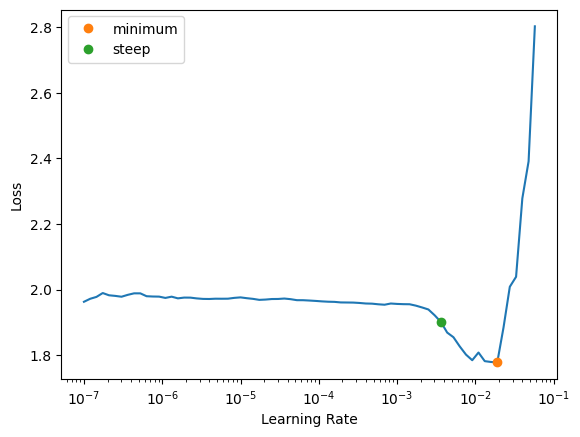

In [23]:
learner.lr_find(suggest_funcs=[minimum, steep])

In [25]:
learner.fit_one_cycle(2, 1.9e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.553052,0.505762,0.817029,01:23
1,0.416673,0.427101,0.844203,01:18


In [26]:
 learner.save("course-classifier-stage-0")

Path('models/course-classifier-stage-0.pth')

In [27]:
learner.export("models/course-classifier-stage-0.pkl")

#Stage-1

In [ ]:
# learner.load("book-classifier-stage-0")

In [28]:
 learner.unfreeze()

<div></div>

SuggestedLRs(slide=9.999999747378752e-06, valley=1.2022644114040304e-05)

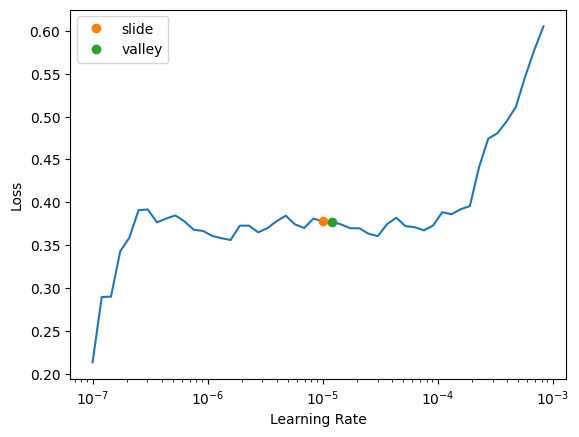

In [29]:
learner.lr_find(suggest_funcs=[slide, valley])

In [30]:
learner.fit_one_cycle(5, slice(1e-6, 1.2e-5))

epoch,train_loss,valid_loss,accuracy,time
0,0.404533,0.433919,0.840580,01:45
1,0.372403,0.429618,0.845109,01:43
2,0.367533,0.426074,0.849638,01:43
3,0.323929,0.420692,0.851449,01:43
4,0.320104,0.420957,0.851449,01:44


In [31]:
learner.save("course-classifier-stage-1")

Path('models/course-classifier-stage-1.pth')

In [32]:
learner.export("models/course-classifier-stage-1.pkl")